In [73]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.weightstats import ttest_ind
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
import statsmodels.api as sm

## Processing DPW data

In [74]:
dpw_raw_pm25 = pd.read_csv("raw PM data/dpw pm25 raw.csv")
dpw_raw_pm25.head()

,timestamp,id,timestamp_local,sn,rh,temp,lat,lon,device_state,pm1,...,no,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id
0,2025-12-31T23:59:55Z,577611969,2025-12-31T18:59:55Z,MOD-00811,49.8,-2.1,41.79521,-71.39783,ACTIVE,6.207,...,6.865,27.876,18.821,16235.0,16236.0,16237.0,18742.0,18743.0,18744.0,18745.0
1,2025-12-31T23:58:55Z,577611968,2025-12-31T18:58:55Z,MOD-00811,49.9,-2.0,41.79521,-71.39783,ACTIVE,6.826,...,6.180,27.884,18.801,16235.0,16236.0,16237.0,18742.0,18743.0,18744.0,18745.0
2,2025-12-31T23:57:55Z,577610031,2025-12-31T18:57:55Z,MOD-00811,49.5,-2.0,41.79521,-71.39783,ACTIVE,5.524,...,5.140,26.688,20.569,16235.0,16236.0,16237.0,18742.0,18743.0,18744.0,18745.0
3,2025-12-31T23:56:55Z,577610033,2025-12-31T18:56:55Z,MOD-00811,49.3,-2.0,41.79521,-71.39783,ACTIVE,6.057,...,4.105,25.880,21.287,16235.0,16236.0,16237.0,18742.0,18743.0,18744.0,18745.0
4,2025-12-31T23:55:55Z,577610032,2025-12-31T18:55:55Z,MOD-00811,49.3,-2.0,41.79521,-71.39783,ACTIVE,5.706,...,6.854,25.880,21.287,16235.0,16236.0,16237.0,18742.0,18743.0,18744.0,18745.0


In [75]:
#remove unnecessary columns, reformat timestamp, filter and resample
dpw_raw_pm25 = dpw_raw_pm25[["timestamp", "rh", "temp", "pm25"]].copy()
dpw_raw_pm25["datetime_utc"] = pd.to_datetime(dpw_raw_pm25["timestamp"], utc=True)
dpw_raw_pm25 = dpw_raw_pm25.drop(columns=["timestamp"])

start = pd.Timestamp("2025-01-02", tz="UTC")
end = pd.Timestamp("2025-08-03 23:59:59", tz="UTC")

dpw_raw_pm25 = dpw_raw_pm25[(dpw_raw_pm25["datetime_utc"] >= start) & (dpw_raw_pm25["datetime_utc"] <= end)]

dpw_raw_pm25 = dpw_raw_pm25.set_index("datetime_utc")
dpw_m1_pm25 = dpw_raw_pm25.resample("1h").mean()
dpw_m1_pm25 = dpw_m1_pm25.reset_index()

dpw_m1_pm25.head()

,datetime_utc,rh,temp,pm25
0,2025-01-02 00:00:00+00:00,70.305000,7.703333,0.841567
1,2025-01-02 01:00:00+00:00,71.536667,6.006667,0.478867
2,2025-01-02 02:00:00+00:00,72.690000,5.530000,0.458833
3,2025-01-02 03:00:00+00:00,69.690000,5.386667,0.442483
4,2025-01-02 04:00:00+00:00,66.933333,5.158333,0.464817


In [76]:
#now need to add in WD WS data from allens Ave
aa_raw_wind = pd.read_csv("raw wind data/AA wind raw.csv")
aa_raw_wind = aa_raw_wind[["date", "ws", "wd"]].copy()
aa_raw_wind["datetime_utc"] = pd.to_datetime(aa_raw_wind["date"], utc=True)
aa_raw_wind = aa_raw_wind.drop(columns=["date"])
aa_raw_wind.head()

,ws,wd,datetime_utc
0,0.9,80.0,2025-01-01 00:00:00+00:00
1,2.1,30.0,2025-01-01 01:00:00+00:00
2,1.5,20.0,2025-01-01 02:00:00+00:00
3,1.5,70.0,2025-01-01 03:00:00+00:00
4,1.5,20.0,2025-01-01 04:00:00+00:00


In [77]:
#merge on datetime
dpw_m2_pm25 = pd.merge(dpw_m1_pm25, aa_raw_wind, on="datetime_utc", how="left")
dpw_m2_pm25.head()

,datetime_utc,rh,temp,pm25,ws,wd
0,2025-01-02 00:00:00+00:00,70.305000,7.703333,0.841567,3.00,290.0
1,2025-01-02 01:00:00+00:00,71.536667,6.006667,0.478867,4.85,300.0
2,2025-01-02 02:00:00+00:00,72.690000,5.530000,0.458833,3.30,280.0
3,2025-01-02 03:00:00+00:00,69.690000,5.386667,0.442483,6.20,270.0
4,2025-01-02 04:00:00+00:00,66.933333,5.158333,0.464817,8.20,280.0


In [78]:
#preparation for ML

#make wind into u-v components rather than polar
dpw_m2_pm25["wd_rad"] = np.deg2rad(dpw_m2_pm25["wd"])
dpw_m2_pm25["wind_u"] = -dpw_m2_pm25["ws"] * np.sin(dpw_m2_pm25["wd_rad"])
dpw_m2_pm25["wind_v"] = -dpw_m2_pm25["ws"] * np.cos(dpw_m2_pm25["wd_rad"])
dpw_m2_pm25 = dpw_m2_pm25.drop(columns=["wd_rad"])

#hour sin/cos to capture cylical patterns
dpw_m2_pm25["hour"] = dpw_m2_pm25["datetime_utc"].dt.hour
dpw_m2_pm25["hour_sin"] = np.sin(2 * np.pi * dpw_m2_pm25["hour"] / 24)
dpw_m2_pm25["hour_cos"] = np.cos(2 * np.pi * dpw_m2_pm25["hour"] / 24)

#create lags
dpw_m2_pm25["pm_lag1"] = dpw_m2_pm25["pm25"].shift(1)
dpw_m2_pm25["pm_lag2"] = dpw_m2_pm25["pm25"].shift(2)
dpw_m2_pm25["pm_lag3"] = dpw_m2_pm25["pm25"].shift(3)
dpw_m2_pm25["pm_lag6"] = dpw_m2_pm25["pm25"].shift(6)
dpw_final_pm25 = dpw_m2_pm25.dropna()


In [79]:
dpw_final_pm25.head()
dpw_final_pm25["pm25_bin"], quintile_bins = pd.qcut(dpw_final_pm25["pm25"], q=5, labels=[0, 1, 2, 3, 4], retbins=True)
print("PM2.5 quintile cutoffs:")
print(quintile_bins)

dpw_final_pm25.head()

PM2.5 quintile cutoffs:
[ 0.21521667  2.28960667  3.67524667  5.64225333  9.39187667 66.98181667]


/var/folders/cv/16s476bd69z2kjqnmm06ls5c0000gn/T/ipykernel_91413/3658868563.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dpw_final_pm25["pm25_bin"], quintile_bins = pd.qcut(dpw_final_pm25["pm25"], q=5, labels=[0, 1, 2, 3, 4], retbins=True)


,datetime_utc,rh,temp,pm25,ws,wd,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin
6,2025-01-02 06:00:00+00:00,58.840000,4.361667,0.494283,9.30,270.0,9.300000,1.708382e-15,6,1.000000,6.123234e-17,0.399550,0.464817,0.442483,0.841567,0
7,2025-01-02 07:00:00+00:00,55.430000,4.113333,0.694683,5.60,260.0,5.514923,9.724298e-01,7,0.965926,-2.588190e-01,0.494283,0.399550,0.464817,0.478867,0
8,2025-01-02 08:00:00+00:00,52.586667,3.908333,0.886617,5.70,280.0,5.613404,-9.897946e-01,8,0.866025,-5.000000e-01,0.694683,0.494283,0.399550,0.458833,0
9,2025-01-02 09:00:00+00:00,50.208333,3.943333,0.952167,7.20,290.0,6.765787,-2.462545e+00,9,0.707107,-7.071068e-01,0.886617,0.694683,0.494283,0.442483,0
10,2025-01-02 10:00:00+00:00,49.291667,4.011667,0.969433,4.45,260.0,4.382395,7.727344e-01,10,0.500000,-8.660254e-01,0.952167,0.886617,0.694683,0.464817,0


In [80]:
dpw_final_pm25["pm25"].describe()

count    4938.000000
mean        6.221975
std         5.356118
min         0.215217
25%         2.642762
50%         4.521225
75%         8.343917
max        66.981817
Name: pm25, dtype: float64

In [81]:
dpw_final_pm25.to_csv("final PM data/dpw_final_pm25.csv", index=False)

/var/folders/cv/16s476bd69z2kjqnmm06ls5c0000gn/T/ipykernel_91413/2832664668.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dpw_final_pm25["wd_rad"] = np.deg2rad(dpw_final_pm25["wd"])


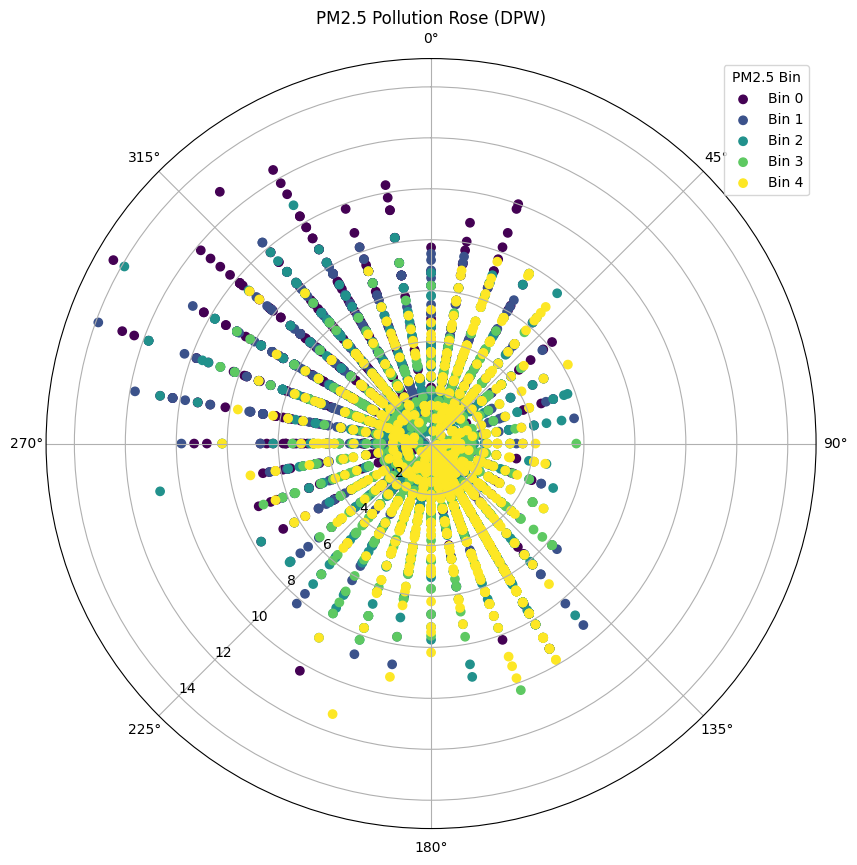

In [82]:
#creating pollution roses
dpw_final_pm25["wd_rad"] = np.deg2rad(dpw_final_pm25["wd"])

n_bins = dpw_final_pm25["pm25_bin"].nunique()
colors = plt.cm.viridis(np.linspace(0, 1, n_bins))

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(10,10))

for b in range(n_bins):
    label_string = "Bin " + str(b)
    subset = dpw_final_pm25[dpw_final_pm25["pm25_bin"] == b]
    #define color based on density of subset
    ax.scatter(subset["wd_rad"], subset["ws"], c=[colors[b]]*len(subset), label=label_string)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_rlabel_position(225)
ax.set_title("PM2.5 Pollution Rose (DPW)")
ax.legend(title="PM2.5 Bin")

plt.savefig("eda plots/DPW pm25 pollution rose.png")
plt.show()

## Processing PEMA data

In [83]:
pema_raw_pm25 = pd.read_csv("raw PM data/pema pm25 raw.csv")
pema_raw_pm25.head()

,timestamp,id,timestamp_local,sn,rh,temp,lat,lon,device_state,wd,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
0,2025-12-31T23:59:48Z,577612542,2025-12-31T18:59:48Z,MOD-00810,50.5,-2.3,41.8522,-71.4198,ACTIVE,246.5,...,23.652,18.138,16071.0,16072.0,16073.0,18738.0,18739.0,18740.0,18741.0,1.72
1,2025-12-31T23:58:48Z,577610523,2025-12-31T18:58:48Z,MOD-00810,50.2,-2.2,41.8522,-71.4198,ACTIVE,243.9,...,24.142,18.481,16071.0,16072.0,16073.0,18738.0,18739.0,18740.0,18741.0,3.64
2,2025-12-31T23:57:48Z,577610521,2025-12-31T18:57:48Z,MOD-00810,50.3,-2.2,41.8522,-71.4198,ACTIVE,259.8,...,24.126,19.385,16071.0,16072.0,16073.0,18738.0,18739.0,18740.0,18741.0,2.70
3,2025-12-31T23:56:48Z,577610524,2025-12-31T18:56:48Z,MOD-00810,50.0,-2.2,41.8522,-71.4198,ACTIVE,241.9,...,23.334,19.654,16071.0,16072.0,16073.0,18738.0,18739.0,18740.0,18741.0,3.30
4,2025-12-31T23:55:48Z,577610522,2025-12-31T18:55:48Z,MOD-00810,49.8,-2.2,41.8522,-71.4198,ACTIVE,261.7,...,21.268,23.022,16071.0,16072.0,16073.0,18738.0,18739.0,18740.0,18741.0,3.79


In [84]:
#remove columns, format, etc. Similar to process before but with no merging needed
pema_raw_pm25 = pema_raw_pm25[["timestamp", "rh", "temp", "wd", "ws", "pm25"]].copy()
pema_raw_pm25["datetime_utc"] = pd.to_datetime(pema_raw_pm25["timestamp"], utc=True)
pema_raw_pm25 = pema_raw_pm25.drop(columns=["timestamp"])

pema_raw_pm25 = pema_raw_pm25[(pema_raw_pm25["datetime_utc"] >= start) & (pema_raw_pm25["datetime_utc"] <= end)]

#resample
pema_raw_pm25 = pema_raw_pm25.set_index("datetime_utc")
pema_raw_pm25 = pema_raw_pm25.resample("1h").mean()

pema_m_pm25 = pema_raw_pm25.reset_index()

pema_m_pm25.head()

,datetime_utc,rh,temp,wd,ws,pm25
0,2025-01-02 00:00:00+00:00,70.066667,7.808333,313.078333,5.714000,0.096833
1,2025-01-02 01:00:00+00:00,73.005000,5.875000,296.005000,4.359833,0.050633
2,2025-01-02 02:00:00+00:00,72.535000,5.458333,279.295000,4.301333,0.047417
3,2025-01-02 03:00:00+00:00,69.446667,5.348333,283.990000,4.909000,0.033750
4,2025-01-02 04:00:00+00:00,67.353333,5.035000,285.388333,4.950167,0.049150


In [85]:
#create features for ML as before

pema_m_pm25["wd_rad"] = np.deg2rad(pema_m_pm25["wd"])
pema_m_pm25["wind_u"] = -pema_m_pm25["ws"] * np.sin(pema_m_pm25["wd_rad"])
pema_m_pm25["wind_v"] = -pema_m_pm25["ws"] * np.cos(pema_m_pm25["wd_rad"])
pema_m_pm25 = pema_m_pm25.drop(columns=["wd_rad"])

pema_m_pm25["hour"] = pema_m_pm25["datetime_utc"].dt.hour
pema_m_pm25["hour_sin"] = np.sin(2 * np.pi * pema_m_pm25["hour"] / 24)
pema_m_pm25["hour_cos"] = np.cos(2 * np.pi * pema_m_pm25["hour"] / 24)

pema_m_pm25["pm_lag1"] = pema_m_pm25["pm25"].shift(1)
pema_m_pm25["pm_lag2"] = pema_m_pm25["pm25"].shift(2)
pema_m_pm25["pm_lag3"] = pema_m_pm25["pm25"].shift(3)
pema_m_pm25["pm_lag6"] = pema_m_pm25["pm25"].shift(6)
pema_final_pm25 = pema_m_pm25.dropna()

In [86]:
pema_final_pm25.head()
pema_final_pm25["pm25_bin"], quintile_bins = pd.qcut(pema_final_pm25["pm25"], q=5, labels=[0, 1, 2, 3, 4], retbins=True)
print("PM2.5 quintile cutoffs:")
print(quintile_bins)

pema_final_pm25.head()

PM2.5 quintile cutoffs:
[3.09833333e-02 5.82923333e-01 1.84566000e+00 4.43118667e+00
 8.15430667e+00 9.18402667e+01]


/var/folders/cv/16s476bd69z2kjqnmm06ls5c0000gn/T/ipykernel_91413/1552066633.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pema_final_pm25["pm25_bin"], quintile_bins = pd.qcut(pema_final_pm25["pm25"], q=5, labels=[0, 1, 2, 3, 4], retbins=True)


,datetime_utc,rh,temp,wd,ws,pm25,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin
6,2025-01-02 06:00:00+00:00,61.271667,3.978333,288.680000,4.513833,0.045150,4.276054,-1.445701,6,1.000000,6.123234e-17,0.040767,0.049150,0.033750,0.096833,0
7,2025-01-02 07:00:00+00:00,57.641667,3.725000,289.245000,5.204833,0.052300,4.913976,-1.715556,7,0.965926,-2.588190e-01,0.045150,0.040767,0.049150,0.050633,0
8,2025-01-02 08:00:00+00:00,53.136667,3.656667,294.898333,5.591833,0.052267,5.072107,-2.354215,8,0.866025,-5.000000e-01,0.052300,0.045150,0.040767,0.047417,0
9,2025-01-02 09:00:00+00:00,50.996667,3.491667,291.131667,4.624833,0.054683,4.313834,-1.667310,9,0.707107,-7.071068e-01,0.052267,0.052300,0.045150,0.033750,0
10,2025-01-02 10:00:00+00:00,50.645000,3.486667,284.775000,4.678333,0.061867,4.523643,-1.193087,10,0.500000,-8.660254e-01,0.054683,0.052267,0.052300,0.049150,0


In [87]:
pema_final_pm25["pm25"].describe()

count    4415.000000
mean        4.755634
std         5.615744
min         0.030983
25%         0.854758
50%         2.961983
75%         6.953933
max        91.840267
Name: pm25, dtype: float64

In [88]:
pema_final_pm25.head()
pema_final_pm25.to_csv("final PM data/pema_final_pm25.csv", index=False)

/var/folders/cv/16s476bd69z2kjqnmm06ls5c0000gn/T/ipykernel_91413/1637837482.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pema_final_pm25["wd_rad"] = np.deg2rad(pema_final_pm25["wd"])


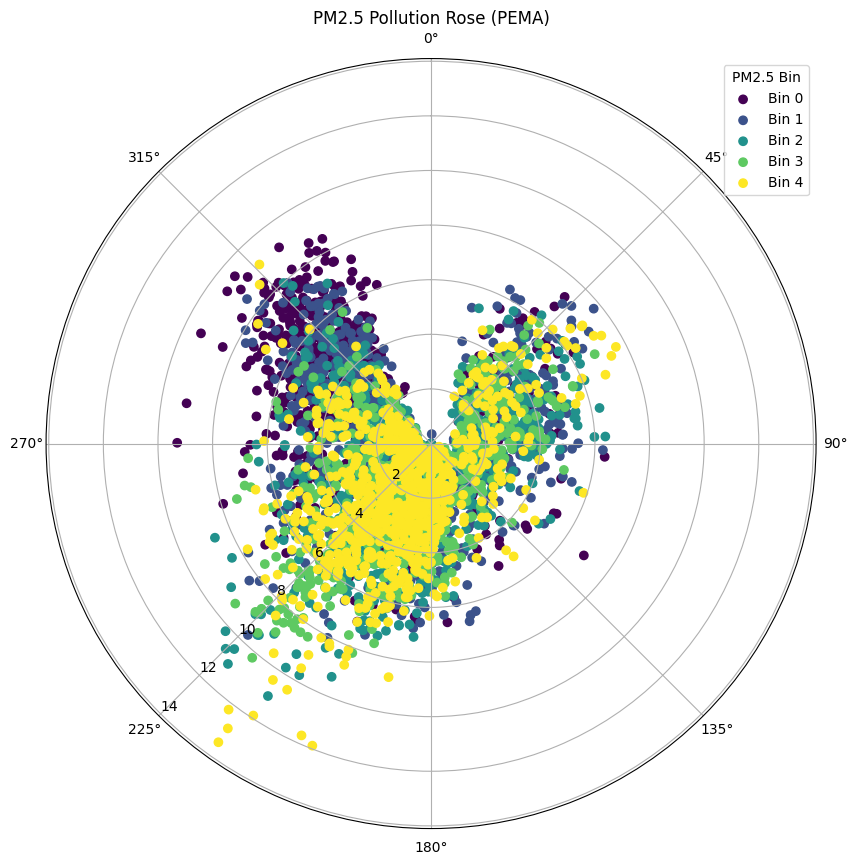

In [89]:
#creating pollution roses
pema_final_pm25["wd_rad"] = np.deg2rad(pema_final_pm25["wd"])

n_bins = pema_final_pm25["pm25_bin"].nunique()
colors = plt.cm.viridis(np.linspace(0, 1, n_bins))

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(10,10))

for b in range(n_bins):
    label_string = "Bin " + str(b)
    subset = pema_final_pm25[pema_final_pm25["pm25_bin"] == b]
    #define color based on density of subset
    ax.scatter(subset["wd_rad"], subset["ws"], c=[colors[b]]*len(subset), label=label_string)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_rlabel_position(225)
ax.set_title("PM2.5 Pollution Rose (PEMA)")
ax.legend(title="PM2.5 Bin")

plt.savefig("eda plots/PEMA pm25 pollution rose.png")
plt.show()

## Processing PHA data

In [90]:
pha_raw_pm25 = pd.read_csv("raw PM data/pha pm25 raw.csv")
pha_raw_pm25.head()

,timestamp,id,timestamp_local,sn,rh,temp,lat,lon,device_state,wd,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
0,2025-12-31T23:59:37Z,577610952,2025-12-31T18:59:37Z,MOD-00812,52.7,-2.9,41.8171,-71.4553,ACTIVE,265.2,...,27.697,14.423,16238.0,16239.0,16240.0,18746.0,18747.0,18748.0,18749.0,7.20
1,2025-12-31T23:58:37Z,577610943,2025-12-31T18:58:37Z,MOD-00812,52.3,-2.9,41.8171,-71.4553,ACTIVE,279.0,...,27.339,15.945,16238.0,16239.0,16240.0,18746.0,18747.0,18748.0,18749.0,9.30
2,2025-12-31T23:57:37Z,577610942,2025-12-31T18:57:37Z,MOD-00812,52.3,-2.9,41.8171,-71.4553,ACTIVE,229.1,...,27.759,15.365,16238.0,16239.0,16240.0,18746.0,18747.0,18748.0,18749.0,8.77
3,2025-12-31T23:56:37Z,577610941,2025-12-31T18:56:37Z,MOD-00812,52.6,-2.9,41.8171,-71.4553,ACTIVE,261.5,...,28.132,12.939,16238.0,16239.0,16240.0,18746.0,18747.0,18748.0,18749.0,7.28
4,2025-12-31T23:55:37Z,577608883,2025-12-31T18:55:37Z,MOD-00812,52.7,-2.9,41.8171,-71.4553,ACTIVE,264.2,...,28.955,12.685,16238.0,16239.0,16240.0,18746.0,18747.0,18748.0,18749.0,6.23


In [91]:
#remove columns, format, etc. Similar to process before but with no merging needed
pha_raw_pm25 = pha_raw_pm25[["timestamp", "rh", "temp", "wd", "ws", "pm25"]].copy()
pha_raw_pm25["datetime_utc"] = pd.to_datetime(pha_raw_pm25["timestamp"], utc=True)
pha_raw_pm25 = pha_raw_pm25.drop(columns=["timestamp"])

pha_raw_pm25 = pha_raw_pm25[(pha_raw_pm25["datetime_utc"] >= start) & (pha_raw_pm25["datetime_utc"] <= end)]

#resample
pha_raw_pm25 = pha_raw_pm25.set_index("datetime_utc")
pha_raw_pm25 = pha_raw_pm25.resample("1h").mean()

pha_m_pm25 = pha_raw_pm25.reset_index()

pha_m_pm25.head()

,datetime_utc,rh,temp,wd,ws,pm25
0,2025-01-02 00:00:00+00:00,71.023333,7.333333,273.293333,2.491500,0.389583
1,2025-01-02 01:00:00+00:00,73.566667,5.595000,273.903333,2.160667,0.214200
2,2025-01-02 02:00:00+00:00,73.408333,5.010000,271.506667,2.746000,0.192533
3,2025-01-02 03:00:00+00:00,70.981667,4.791667,269.335000,2.488000,0.198267
4,2025-01-02 04:00:00+00:00,68.388333,4.468333,274.261667,2.607333,0.168467


In [92]:
#create features for ML as before

pha_m_pm25["wd_rad"] = np.deg2rad(pha_m_pm25["wd"])
pha_m_pm25["wind_u"] = -pha_m_pm25["ws"] * np.sin(pha_m_pm25["wd_rad"])
pha_m_pm25["wind_v"] = -pha_m_pm25["ws"] * np.cos(pha_m_pm25["wd_rad"])
pha_m_pm25 = pha_m_pm25.drop(columns=["wd_rad"])

pha_m_pm25["hour"] = pha_m_pm25["datetime_utc"].dt.hour
pha_m_pm25["hour_sin"] = np.sin(2 * np.pi * pha_m_pm25["hour"] / 24)
pha_m_pm25["hour_cos"] = np.cos(2 * np.pi * pha_m_pm25["hour"] / 24)

pha_m_pm25["pm_lag1"] = pha_m_pm25["pm25"].shift(1)
pha_m_pm25["pm_lag2"] = pha_m_pm25["pm25"].shift(2)
pha_m_pm25["pm_lag3"] = pha_m_pm25["pm25"].shift(3)
pha_m_pm25["pm_lag6"] = pha_m_pm25["pm25"].shift(6)
pha_final_pm25 = pha_m_pm25.dropna()

In [93]:
pha_final_pm25.head()
pha_final_pm25["pm25_bin"], quintile_bins = pd.qcut(pha_final_pm25["pm25"], q=5, labels=[0, 1, 2, 3, 4], retbins=True)
print("PM2.5 quintile cutoffs:")
print(quintile_bins)

pha_final_pm25.head()

PM2.5 quintile cutoffs:
[1.19366667e-01 1.25121667e+00 2.49470000e+00 4.27413333e+00
 7.35301667e+00 1.28021000e+02]


/var/folders/cv/16s476bd69z2kjqnmm06ls5c0000gn/T/ipykernel_91413/66080973.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pha_final_pm25["pm25_bin"], quintile_bins = pd.qcut(pha_final_pm25["pm25"], q=5, labels=[0, 1, 2, 3, 4], retbins=True)


,datetime_utc,rh,temp,wd,ws,pm25,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin
6,2025-01-02 06:00:00+00:00,62.023333,3.330000,261.698333,2.648500,0.207967,2.620748,0.382404,6,1.000000,6.123234e-17,0.165667,0.168467,0.198267,0.389583,0
7,2025-01-02 07:00:00+00:00,58.768333,3.020000,270.975000,2.878667,0.295167,2.878250,-0.048984,7,0.965926,-2.588190e-01,0.207967,0.165667,0.168467,0.214200,0
8,2025-01-02 08:00:00+00:00,55.421667,2.898333,273.275000,2.903833,0.309267,2.899091,-0.165891,8,0.866025,-5.000000e-01,0.295167,0.207967,0.165667,0.192533,0
9,2025-01-02 09:00:00+00:00,53.240000,2.845000,273.426667,2.866000,0.312800,2.860876,-0.171304,9,0.707107,-7.071068e-01,0.309267,0.295167,0.207967,0.198267,0
10,2025-01-02 10:00:00+00:00,52.566667,2.850000,266.546667,2.758667,0.346200,2.753657,0.166170,10,0.500000,-8.660254e-01,0.312800,0.309267,0.295167,0.168467,0


In [94]:
pha_final_pm25["pm25"].describe()

count    4401.000000
mean        4.683284
std         5.140638
min         0.119367
25%         1.492800
50%         3.245600
75%         6.404100
max       128.021000
Name: pm25, dtype: float64

In [95]:
pha_final_pm25.head()
pha_final_pm25.to_csv("final PM data/pha_final_pm25.csv", index=False)

/var/folders/cv/16s476bd69z2kjqnmm06ls5c0000gn/T/ipykernel_91413/1211303151.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pha_final_pm25["wd_rad"] = np.deg2rad(pha_final_pm25["wd"])


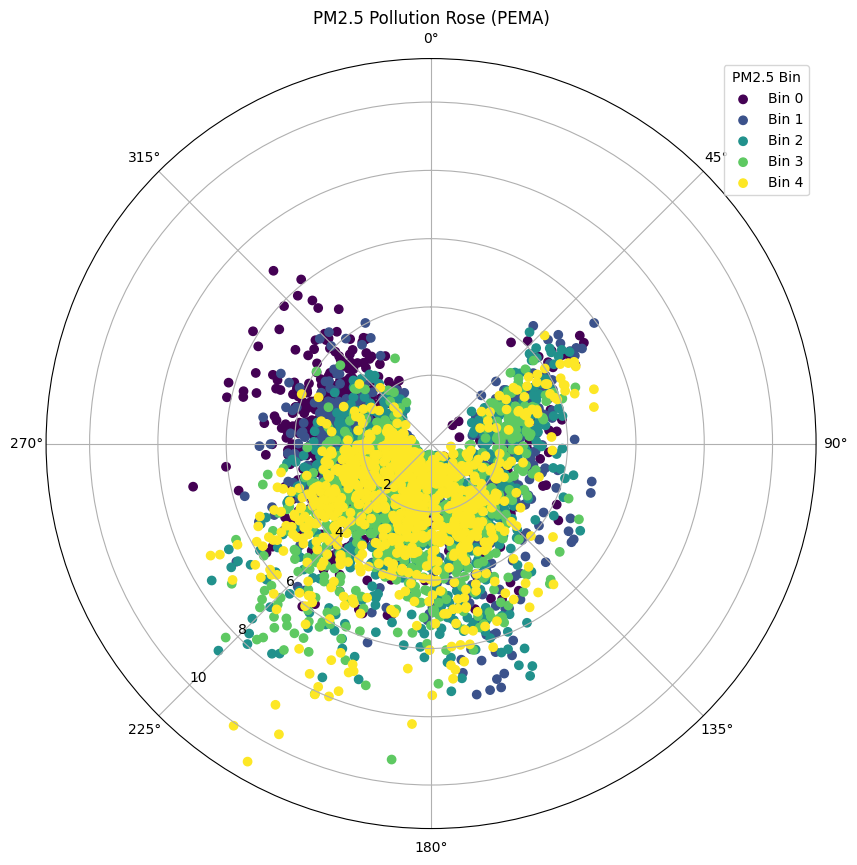

In [96]:
#creating pollution roses
pha_final_pm25["wd_rad"] = np.deg2rad(pha_final_pm25["wd"])

n_bins = pha_final_pm25["pm25_bin"].nunique()
colors = plt.cm.viridis(np.linspace(0, 1, n_bins))

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(10,10))

for b in range(n_bins):
    label_string = "Bin " + str(b)
    subset = pha_final_pm25[pha_final_pm25["pm25_bin"] == b]
    #define color based on density of subset
    ax.scatter(subset["wd_rad"], subset["ws"], c=[colors[b]]*len(subset), label=label_string)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_rlabel_position(225)
ax.set_title("PM2.5 Pollution Rose (PEMA)")
ax.legend(title="PM2.5 Bin")

plt.savefig("eda plots/PHA pm25 pollution rose.png")
plt.show()